In [ ]:
# ==========================================================
#                   Universidad Franz Tamayo
# ----------------------------------------------------------
#                        MINERIA DE DATOS
# ----------------------------------------------------------
#        Enrique Alejandro Laurel Cossio, May 2026
# ==========================================================
#  Modelos de Agrupamiento (Clustering): Conceptos y Aplicación
# ==========================================================

Los modelos de mineria de datos o machine learning

- SUPERVISADOS 
Es necesario definir la etiqueta o variable objetivo 
    - CLASIFICACIÓN
        - Regresión Logística
        - Arboles de Decisiones 
        - H2O
    - REGRESIÓN
        - Regresión Lineal 
        - Arboles de Decisión
        - H2O
- NO SUPERVISADOS
No es necesario definir una variable objetivo

# Modelos de Agrupamiento (Clustering)

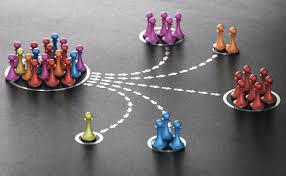

## Parte 1: Conceptos Fundamentales

### ¿Qué son los Modelos de Agrupamiento?

Los modelos de agrupamiento (clustering) son algoritmos de **aprendizaje no supervisado** que buscan agrupar observaciones similares en grupos (clusters) sin necesidad de una variable objetivo o etiqueta predefinida.

A diferencia de la **clasificación** (supervisada), donde tenemos etiquetas predefinidas, en el clustering **el modelo descubre patrones y similitudes en los datos por sí solo**.

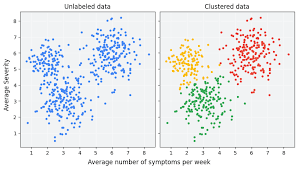

### ¿Para qué Sirven?

1. **Segmentación de Clientes:** Agrupar clientes por similitud en comportamiento, ingresos, preferencias.
2. **Análisis de Productos:** Encontrar categorías naturales de productos basadas en características.
3. **Detección de Anomalías:** Identificar puntos que no pertenecen a ningún grupo (outliers).
4. **Reducción de Datos:** Simplificar datasets agrupando observaciones similares.
5. **Descubrimiento de Conocimiento:** Entender estructura oculta en los datos.

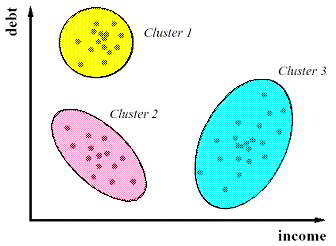

### Cuál es el Fin

El objetivo principal es **minimizar la variabilidad dentro de los grupos (intra-cluster) y maximizar la variabilidad entre grupos (inter-cluster)**. En otras palabras:

- Observaciones **similares deben estar juntas**.
- Observaciones **diferentes deben estar separadas**.

### Aprendizaje No Supervisado vs Supervisado

| Aspecto | Supervisado | No Supervisado |
|---------|------------|----------------|
| Variable Objetivo | Sí (clasificación/regresión) | No |
| Etiquetas | Predefinidas | Descubiertas por el modelo |
| Objetivo | Predecir una clase o valor | Encontrar patrones y estructura |
| Ejemplos | Regresión Logística, Árboles, SVM | K-Means, Hierarchical, DBSCAN |



## Parte 2: Tipos de Modelos de Agrupamiento

### Clasificación por Tipo de Variables

#### A. Modelos para Variables Numéricas

Estos modelos trabajan con distancias euclidianas o similares:

1. **K-Means** (Más Simple)
   - Particiona datos en k clusters.
   - Rápido y escalable.
   - Requiere especificar k de antemano.
   - Sensible a outliers.
   - centros o centroides de cada cluster es el promedio 

2. **K-Medoids**
   - Variante robusta de K-Means.
   - Usa puntos reales (medoids) en lugar de centroides.
   - Más resistente a outliers.
   - centros son las medianas de cada grupo

3. **Agrupamiento Jerárquico (Hierarchical Clustering)**
   - Crea dendrogramas mostrando relaciones entre clusters.
   - No requiere especificar k de antemano.
   - Variantes: Aglomerativo (bottom-up) y Divisivo (top-down).

4. **DBSCAN** (Density-Based)
   - Agrupa basándose en densidad de puntos.
   - Descubre clusters de forma arbitraria.
   - Identifica outliers automáticamente.
   - No requiere especificar k.

5. **Gaussian Mixture Models (GMM)**
   - Modelo probabilístico que asume distribuciones gaussianas.
   - Probabilidades suaves de membresía.
   - Más complejo que K-Means pero más flexible.

#### B. Modelos para Variables Mixtas (Numéricas + Categóricas)

1. **K-Prototype**
   - Combina K-Means (variables numéricas) con modos de categorías.
   - Diseñado específicamente para datos mixtos.

2. **KAMILA (K-means for MIxed LArge data)**
   - Extiende K-Means a variables mixtas.
   - Maneja datasets grandes.

3. **Agrupamiento Basado en Gower**
   - Usa distancia de Gower para variables mixtas.
   - Combina distancia euclidiana para numéricas y distancia categórica.
   - Flexible y compatible con cualquier algoritmo que use matrices de distancia.

### Tabla Comparativa

| Modelo | Tipo de Datos | Complejidad | Requiere k | Robusto a Outliers | Escalabilidad |
|--------|---------------|-------------|------------|-------------------|---------------|
| K-Means | Numéricos | Baja | Sí | No | Muy Alta |
| K-Medoids | Numéricos | Media | Sí | Sí | Media |
| Hierarchical | Numéricos | Media | No | Media | Baja |
| DBSCAN | Numéricos | Alta | No | Sí | Media-Alta |
| GMM | Numéricos | Alta | Sí | No | Media |
| K-Prototype | Mixtos | Media | Sí | No | Media |
| Gower + Algoritmo | Mixtos | Variable | Variable | Variable | Variable |


## Parte 3: Conceptos Básicos del Agrupamiento

### 3.1 Medidas de Distancia

Los algoritmos de clustering necesitan saber qué tan "lejos" están los puntos entre sí.

#### Distancia Euclidiana
```
d(A, B) = √[(x₁-y₁)² + (x₂-y₂)² + ... + (xₙ-yₙ)²]
```
Usada en K-Means y otros algoritmos de variables numéricas.

#### Distancia de Manhattan
```
d(A, B) = |x₁-y₁| + |x₂-y₂| + ... + |xₙ-yₙ|
```

#### Distancia de Gower
```
Para variables numéricas: distancia normalizada
Para variables categóricas: 0 si son iguales, 1 si son diferentes
```
Ideal para datos mixtos.

### 3.2 Normalización de Datos

Muy importante: si una variable está en escala 1-1000 y otra en 0-1, el clustering se sesgará hacia la primera.

```python
# Estandarización (Z-score normalization)
z_scaled = (x - mean) / std

# Min-Max normalization
min_max = (x - min) / (max - min)
```

### 3.3 Codificación de Variables Categóricas

Para usar variables categóricas:

1. **One-Hot Encoding:** Crea columna binaria por categoría.
2. **Label Encoding:** Asigna números a categorías (cuidado: implica orden).
3. **Métodos Específicos:** Algunos algoritmos (K-Prototype) manejan categorías nativamente.


## Parte 4: Detalles Técnicos de Algoritmos Principales

### K-Means: Paso a Paso

1. **Inicialización:** Selecciona k puntos aleatorios como centroides iniciales.
2. **Asignación:** Cada punto se asigna al centroide más cercano.
3. **Actualización:** Recalcula cada centroide como el promedio de sus puntos.
4. **Iteración:** Repite pasos 2-3 hasta convergencia (cambio mínimo de centroides).

**Ventajas:** Rápido, simple, escalable.

**Desventajas:** 
- Requiere especificar k de antemano.
- Sensible a inicialización.
- Puede converger en óptimos locales.
- Asume clusters esféricos.

### Agrupamiento Jerárquico

**Aglomerativo (Bottom-Up):**
1. Cada punto comienza en su propio cluster.
2. Se fusionan iterativamente los dos clusters más cercanos.
3. Produce un dendrograma.

**Métodos de Vinculación:**
- Single Linkage: distancia entre puntos más cercanos.
- Complete Linkage: distancia entre puntos más lejanos.
- Average Linkage: distancia promedio.
- Ward Linkage: minimiza varianza intra-cluster.

### DBSCAN: Clustering Basado en Densidad

**Parámetros:**
- `eps`: Radio de vecindad.
- `min_samples`: Mínimo de puntos para formar un cluster core.

**Clasificación de Puntos:**
- **Core Points:** Más de min_samples en su eps-vecindad.
- **Border Points:** En eps-vecindad de un core point pero no core.
- **Noise (Outliers):** No cumple ningún criterio.

**Ventajas:** Descubre clusters de forma arbitraria, identifica outliers.

**Desventajas:** Sensible a eps y min_samples, problemas con clusters de densidad variable.


## Parte 5: Evaluación de Clustering

Sin etiquetas verdaderas, ¿cómo sabemos si nuestro clustering es bueno?

### Métricas Internas (sin etiquetas verdaderas)

1. **Silhouette Score** (Coeficiente de Silueta)
   - Mide cuán similar es una observación a su cluster vs otros clusters.
   - Rango: -1 a 1 (1 es excelente, -1 es malo, 0 es overlapping).
   - Fórmula: `silhouette = (b - a) / max(a, b)`
     - a = distancia promedio dentro del cluster.
     - b = distancia promedio al cluster más cercano.

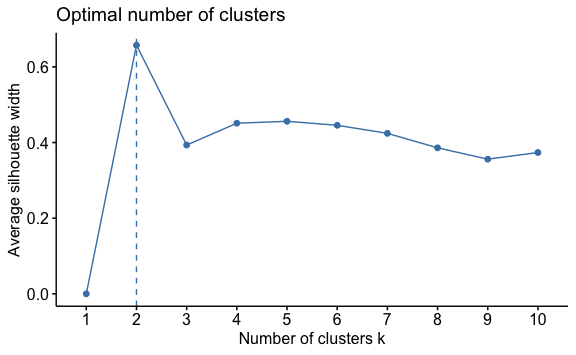

2. **Davies-Bouldin Index**
   - Ratio entre similitud intra-cluster e inter-cluster.
   - Menor es mejor (valores cercanos a 0).

3. **Calinski-Harabasz Index**
   - Ratio de varianza inter-cluster a intra-cluster.
   - Mayor es mejor.

4. **Inercia (Dentro de K-Means)**
   - Suma de distancias cuadradas de cada punto a su centroide.
   - Menor es mejor, pero siempre disminuye con más clusters (curva del codo).

### Método del Codo

Para K-Means, graficar inercia vs k. El "codo" (cambio de pendiente) sugiere el k óptimo.
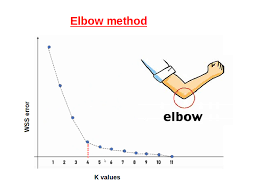


## Parte 6: Checklist de Implementación

1. **Carga y Exploración:** Entender estructura, tipos de datos, valores faltantes.
2. **Preprocesamiento:**
   - Manejar valores faltantes.
   - Seleccionar variables relevantes.
   - Codificar variables categóricas.
   - Normalizar/Estandarizar.
3. **Selección de Algoritmo:** Según tipo de datos y características deseadas.
4. **Determinar Número de Clusters:** Método del codo, silueta, dominio.
5. **Ajuste de Hiperparámetros:** eps, min_samples, linkage, etc.
6. **Entrenamiento:** Ejecutar algoritmo.
7. **Evaluación:** Usar métricas internas.
8. **Validación:** Interpretar clusters (¿tienen sentido?).
9. **Visualización:** Gráficos en 2D/3D para entender estructura.
10. **Persistencia:** Guardar modelo para predicciones futuras.


---

# Parte 7: Ejemplo Práctico - Clustering con Variables Numéricas y Categóricas

## 1. LIBRERÍAS Y PREPARACIÓN

In [1]:
# Librerías estándar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Para distancia de Gower y K-Prototype
from gower import gower_matrix
#from kmodes.kmodes.kprototypes import KPrototypes
from kmodes.kprototypes import KPrototypes

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. CARGA Y EXPLORACIÓN DE DATOS

In [3]:
# Cargar datos (usamos el dataset ifood nuevamente)
df = pd.read_csv('data/ifood.csv', sep=',', encoding='iso-8859-1')

print(f"Forma del dataset: {df.shape}")
print(f"\nPrimeras filas:")
print(df.head(2))

print(f"\nTipos de datos:")
print(df.dtypes)

print(f"\nValores faltantes:")
print(df.isnull().sum())
df.head(2)

Forma del dataset: (2240, 29)

Primeras filas:
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  2012-09-04       58       635  ...                  7             0   
1  2014-03-08       38        11  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0             0             0             0             0         0   
1             0             0             0             0         0   

   Z_CostContact  Z_Revenue  Response  
0              3         11         1  
1              3         11         0  

[2 rows x 29 columns]

Tipos de datos:
ID                       int64
Year_Birth               int64
Education                  str
Marital_Status             s

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0


## 3. PREPROCESAMIENTO

In [4]:
# Crear una copia para preprocesar
df_cluster = df.copy()

# 3.1. Manejar valores faltantes
df_cluster['Income'] = df_cluster['Income'].fillna(df_cluster['Income'].median())

# 3.2. Seleccionar variables para clustering
# Variables numéricas
numeric_features = ['Income', 'Recency', 'MntWines', 'MntMeatProducts', 'NumWebPurchases']

# Variables categóricas
categorical_features = ['Education', 'Marital_Status']

# Todas las características
all_features = numeric_features + categorical_features

# Seleccionar datos
df_cluster = df_cluster[all_features].copy()

print(f"Dataset para clustering - Forma: {df_cluster.shape}")
print(f"\nNumerics: {numeric_features}")
print(f"Categoricals: {categorical_features}")
print(f"\nDatos de muestra:")
print(df_cluster.head())

Dataset para clustering - Forma: (2240, 7)

Numerics: ['Income', 'Recency', 'MntWines', 'MntMeatProducts', 'NumWebPurchases']
Categoricals: ['Education', 'Marital_Status']

Datos de muestra:
    Income  Recency  MntWines  MntMeatProducts  NumWebPurchases   Education  \
0  58138.0       58       635              546                8  Graduation   
1  46344.0       38        11                6                1  Graduation   
2  71613.0       26       426              127                8  Graduation   
3  26646.0       26        11               20                2  Graduation   
4  58293.0       94       173              118                5         PhD   

  Marital_Status  
0         Single  
1         Single  
2       Together  
3       Together  
4        Married  


In [5]:
df_cluster.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Income           2240 non-null   float64
 1   Recency          2240 non-null   int64  
 2   MntWines         2240 non-null   int64  
 3   MntMeatProducts  2240 non-null   int64  
 4   NumWebPurchases  2240 non-null   int64  
 5   Education        2240 non-null   str    
 6   Marital_Status   2240 non-null   str    
dtypes: float64(1), int64(4), str(2)
memory usage: 122.6 KB


In [7]:
df_cluster.describe()

,Income,Recency,MntWines,MntMeatProducts,NumWebPurchases
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,52237.975446,49.109375,303.935714,166.950000,4.084821
std,25037.955891,28.962453,336.597393,225.715373,2.778714
min,1730.000000,0.000000,0.000000,0.000000,0.000000
25%,35538.750000,24.000000,23.750000,16.000000,2.000000
50%,51381.500000,49.000000,173.500000,67.000000,4.000000
75%,68289.750000,74.000000,504.250000,232.000000,6.000000
max,666666.000000,99.000000,1493.000000,1725.000000,27.000000


In [6]:
# 3.3. Codificación de variables categóricas
# Para K-Prototype, necesitamos convertir categóricas a códigos numéricos

from sklearn.preprocessing import LabelEncoder

df_encoded = df_cluster.copy()
le_dict = {}

for col in categorical_features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\nDataset codificado:")
print(df_encoded.head())

Education: {'2n Cycle': np.int64(0), 'Basic': np.int64(1), 'Graduation': np.int64(2), 'Master': np.int64(3), 'PhD': np.int64(4)}
Marital_Status: {'Absurd': np.int64(0), 'Alone': np.int64(1), 'Divorced': np.int64(2), 'Married': np.int64(3), 'Single': np.int64(4), 'Together': np.int64(5), 'Widow': np.int64(6), 'YOLO': np.int64(7)}

Dataset codificado:
    Income  Recency  MntWines  MntMeatProducts  NumWebPurchases  Education  \
0  58138.0       58       635              546                8          2   
1  46344.0       38        11                6                1          2   
2  71613.0       26       426              127                8          2   
3  26646.0       26        11               20                2          2   
4  58293.0       94       173              118                5          4   

   Marital_Status  
0               4  
1               4  
2               5  
3               5  
4               3  


In [8]:
# 3.4. Normalización de variables numéricas
# Es crucial para que K-Means y otros algoritmos no estén sesgados

scaler = StandardScaler()
df_normalized = df_encoded.copy()

# Normalizar solo variables numéricas
df_normalized[numeric_features] = scaler.fit_transform(df_normalized[numeric_features])

print("Datos normalizados:")
print(df_normalized.head())
print(f"\nMean de variables numéricas (después de normalización):")
print(df_normalized[numeric_features].mean())
print(f"\nStd de variables numéricas (después de normalización):")
print(df_normalized[numeric_features].std())

Datos normalizados:
     Income   Recency  MntWines  MntMeatProducts  NumWebPurchases  Education  \
0  0.235696  0.307039  0.983781         1.679702         1.409304          2   
1 -0.235454 -0.383664 -0.870479        -0.713225        -1.110409          2   
2  0.773999 -0.798086  0.362723        -0.177032         1.409304          2   
3 -1.022355 -0.798086 -0.870479        -0.651187        -0.750450          2   
4  0.241888  1.550305 -0.389085        -0.216914         0.329427          4   

   Marital_Status  
0               4  
1               4  
2               5  
3               5  
4               3  

Mean de variables numéricas (después de normalización):
Income            -4.361590e-17
Recency           -3.172066e-18
MntWines          -7.612958e-17
MntMeatProducts    4.123686e-17
NumWebPurchases   -5.709718e-17
dtype: float64

Std de variables numéricas (después de normalización):
Income             1.000223
Recency            1.000223
MntWines           1.000223
MntMeat

## 4. DETERMINACIÓN DEL NÚMERO ÓPTIMO DE CLUSTERS (MÉTODO DEL CODO)

In [9]:
# Probamos diferentes valores de k
inercias = []
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_normalized)
    
    inercias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_normalized, kmeans.labels_))
    
    print(f"k={k}: Inercia={kmeans.inertia_:.2f}, Silhouette={silhouette_scores[-1]:.4f}")

k=2: Inercia=12401.50, Silhouette=0.2520
k=3: Inercia=11226.30, Silhouette=0.1647
k=4: Inercia=10176.41, Silhouette=0.1651
k=5: Inercia=9400.31, Silhouette=0.1707
k=6: Inercia=8768.41, Silhouette=0.1684
k=7: Inercia=8254.31, Silhouette=0.1657
k=8: Inercia=7747.31, Silhouette=0.1698
k=9: Inercia=7328.08, Silhouette=0.1681
k=10: Inercia=6983.79, Silhouette=0.1687


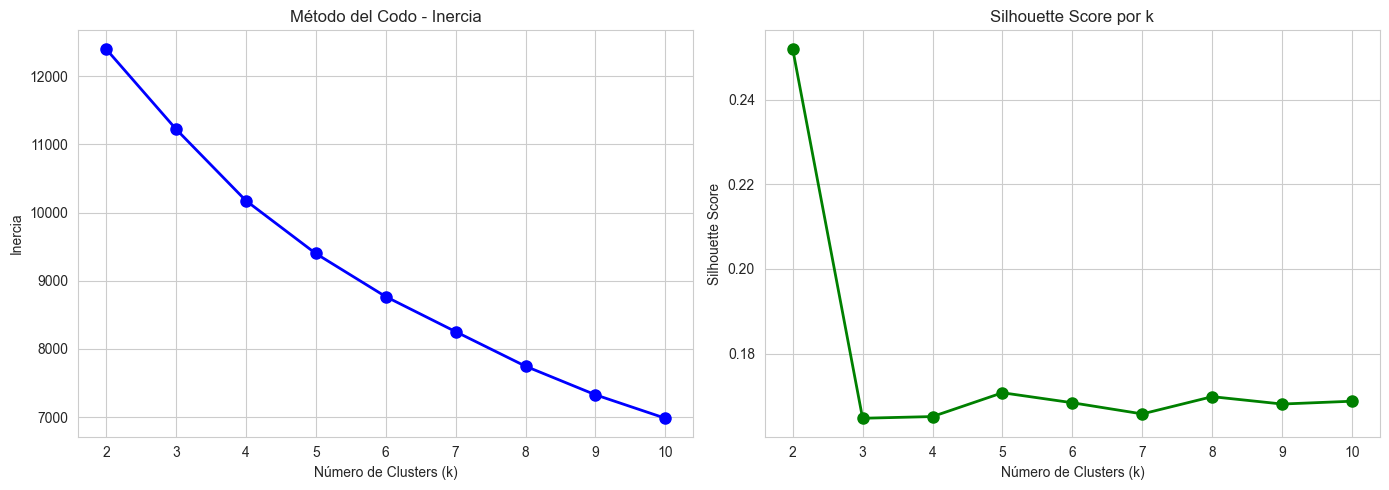


k óptimo según Silhouette: 2
Mejor Silhouette Score: 0.2520


In [10]:
# Graficar el método del codo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de inercia
axes[0].plot(k_values, inercias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo - Inercia')
axes[0].grid(True)

# Gráfico de Silhouette
axes[1].plot(k_values, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por k')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"\nk óptimo según Silhouette: {k_values[np.argmax(silhouette_scores)]}")
print(f"Mejor Silhouette Score: {max(silhouette_scores):.4f}")

## 5. ALGORITMO 1: K-MEANS (SOLO VARIABLES NUMÉRICAS)

In [11]:
optimal_k = k_values[np.argmax(silhouette_scores)]
optimal_k

2

In [12]:
# K-Means requiere solo variables numéricas
df_numeric_only = df_normalized[numeric_features].copy()

# Entrenar K-Means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_cluster['KMeans_Label'] = kmeans.fit_predict(df_numeric_only)

print(f"K-Means entrenado con k={optimal_k}")
print(f"\nDistribución de clusters:")
print(df_cluster['KMeans_Label'].value_counts().sort_index())

# Métricas
silhouette_kmeans = silhouette_score(df_numeric_only, df_cluster['KMeans_Label'])
davies_bouldin_kmeans = davies_bouldin_score(df_numeric_only, df_cluster['KMeans_Label'])
calinski_kmeans = calinski_harabasz_score(df_numeric_only, df_cluster['KMeans_Label'])

print(f"\nMétricas K-Means:")
print(f"Silhouette Score: {silhouette_kmeans:.4f} (mejor: 1, peor: -1)")
print(f"Davies-Bouldin Index: {davies_bouldin_kmeans:.4f} (menor es mejor)")
print(f"Calinski-Harabasz Index: {calinski_kmeans:.4f} (mayor es mejor)")

K-Means entrenado con k=2

Distribución de clusters:
KMeans_Label
0    1242
1     998
Name: count, dtype: int64

Métricas K-Means:
Silhouette Score: 0.3686 (mejor: 1, peor: -1)
Davies-Bouldin Index: 1.1548 (menor es mejor)
Calinski-Harabasz Index: 1339.0493 (mayor es mejor)


## 6. ALGORITMO 2: K-PROTOTYPE (VARIABLES NUMÉRICAS Y CATEGÓRICAS)

In [ ]:
# K-Prototype maneja directamente variables mixtas
# Necesitamos indicar qué columnas son categóricas

# Convertir a array numpy
X_kproto = df_encoded[all_features].values

# Indices de columnas categóricas
categorical_indices = [len(numeric_features) + i for i in range(len(categorical_features))]

# Entrenar K-Prototype
kproto = KPrototypes(n_clusters=optimal_k, init='Huang', verbose=0, random_state=42)
df_cluster['KPrototype_Label'] = kproto.fit_predict(X_kproto, categorical_indices=categorical_indices)

print(f"K-Prototype entrenado con k={optimal_k}")
print(f"\nDistribución de clusters:")
print(pd.Series(df_cluster['KPrototype_Label']).value_counts().sort_index())

print(f"\nCosto final: {kproto.cost_}")

In [39]:
# K-Prototype maneja directamente variables mixtas
# Necesitamos indicar qué columnas son categóricas

# Convertir a array numpy
X_kproto = df_encoded[all_features].values

# Indices de columnas categóricas
categorical_indices = [len(numeric_features) + i for i in range(len(categorical_features))]

# Entrenar K-Prototype
kproto = KPrototypes(n_clusters=optimal_k, init='Huang', verbose=0, random_state=42)
kproto.fit(X_kproto, categorical=categorical_indices)
df_cluster['KPrototype_Label'] = kproto.predict(X_kproto, categorical=categorical_indices)

print(f"K-Prototype entrenado con k={optimal_k}")
print(f"\nDistribución de clusters:")
print(pd.Series(df_cluster['KPrototype_Label']).value_counts().sort_index())

print(f"\nCosto final: {kproto.cost_}")

K-Prototype entrenado con k=2

Distribución de clusters:
KPrototype_Label
0    1055
1    1185
Name: count, dtype: int64

Costo final: 681036892838.4906


In [41]:
df_cluster.head(2)

,Income,Recency,MntWines,MntMeatProducts,NumWebPurchases,Education,Marital_Status,KMeans_Label,KPrototype_Label
0,58138.0,58,635,546,8,Graduation,Single,1,0
1,46344.0,38,11,6,1,Graduation,Single,0,1


## 7. ALGORITMO 3: HIERARCHICAL CLUSTERING

In [ ]:
# Agrupamiento jerárquico con linkage='ward' (variables numéricas)
hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
df_cluster['Hierarchical_Label'] = hierarchical.fit_predict(df_numeric_only)

print(f"Hierarchical Clustering entrenado con k={optimal_k}")
print(f"\nDistribución de clusters:")
print(df_cluster['Hierarchical_Label'].value_counts().sort_index())

# Métricas
silhouette_hier = silhouette_score(df_numeric_only, df_cluster['Hierarchical_Label'])
davies_bouldin_hier = davies_bouldin_score(df_numeric_only, df_cluster['Hierarchical_Label'])
calinski_hier = calinski_harabasz_score(df_numeric_only, df_cluster['Hierarchical_Label'])

print(f"\nMétricas Hierarchical:")
print(f"Silhouette Score: {silhouette_hier:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_hier:.4f}")
print(f"Calinski-Harabasz Index: {calinski_hier:.4f}")

Hierarchical Clustering entrenado con k=2

Distribución de clusters:
Hierarchical_Label
0    1075
1    1165
Name: count, dtype: int64

Métricas Hierarchical:
Silhouette Score: 0.3383
Davies-Bouldin Index: 1.2047
Calinski-Harabasz Index: 1200.6738


## 8. ALGORITMO 4: DBSCAN

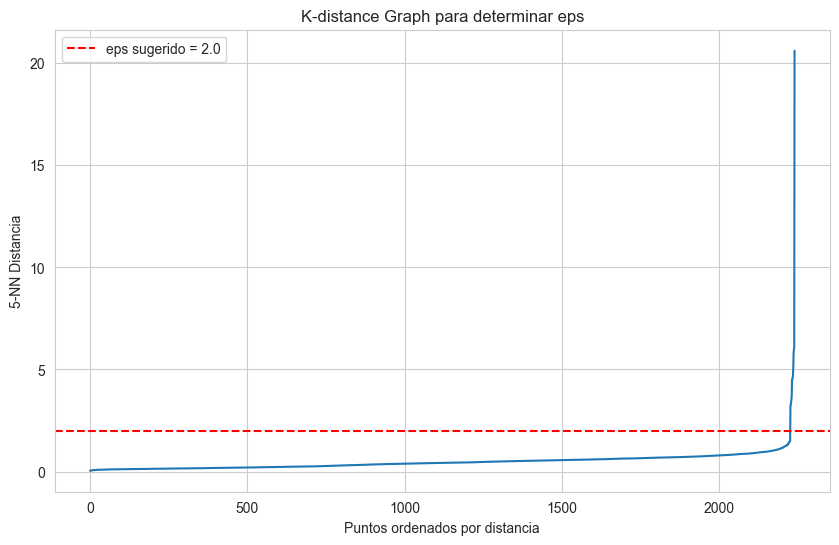

DBSCAN entrenado con eps=2.0, min_samples=4

Número de clusters encontrados: 3
Número de outliers (etiqueta -1): 10

Distribución de clusters:
DBSCAN_Label
-1      10
 0    2226
 1       4
Name: count, dtype: int64

Métricas DBSCAN (excluyendo outliers):
Silhouette Score: 0.4623
Davies-Bouldin Index: 0.6239
Calinski-Harabasz Index: 18.8583


In [47]:
from sklearn.neighbors import NearestNeighbors

# DBSCAN Clustering
# Necesitamos encontrar los parámetros óptimos: eps y min_samples


# Gráfico de k-distance para determinar eps
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(df_numeric_only)
distances, indices = neighbors_fit.kneighbors(df_numeric_only)
distances = np.sort(distances[:, -1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Puntos ordenados por distancia')
plt.ylabel('5-NN Distancia')
plt.title('K-distance Graph para determinar eps')
plt.grid(True)
plt.axhline(y=2.0, color='r', linestyle='--', label='eps sugerido = 2.0')
plt.legend()
plt.show()

# Entrenar DBSCAN con parámetros seleccionados
eps = 2.0
min_samples = 4

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
df_cluster['DBSCAN_Label'] = dbscan.fit_predict(df_numeric_only)

# Información sobre clusters
n_clusters_dbscan = len(set(df_cluster['DBSCAN_Label'])) - (1 if -1 in df_cluster['DBSCAN_Label'] else 0)
n_outliers = (df_cluster['DBSCAN_Label'] == -1).sum()

print(f"DBSCAN entrenado con eps={eps}, min_samples={min_samples}")
print(f"\nNúmero de clusters encontrados: {n_clusters_dbscan}")
print(f"Número de outliers (etiqueta -1): {n_outliers}")
print(f"\nDistribución de clusters:")
print(df_cluster['DBSCAN_Label'].value_counts().sort_index())

# Métricas (solo para puntos que no son outliers)
if n_clusters_dbscan > 1:
    mask = df_cluster['DBSCAN_Label'] != -1
    silhouette_dbscan = silhouette_score(df_numeric_only[mask], df_cluster.loc[mask, 'DBSCAN_Label'])
    davies_bouldin_dbscan = davies_bouldin_score(df_numeric_only[mask], df_cluster.loc[mask, 'DBSCAN_Label'])
    calinski_dbscan = calinski_harabasz_score(df_numeric_only[mask], df_cluster.loc[mask, 'DBSCAN_Label'])
    
    print(f"\nMétricas DBSCAN (excluyendo outliers):")
    print(f"Silhouette Score: {silhouette_dbscan:.4f}")
    print(f"Davies-Bouldin Index: {davies_bouldin_dbscan:.4f}")
    print(f"Calinski-Harabasz Index: {calinski_dbscan:.4f}")
else:
    print(f"\nDBSCAN no encontró clusters significativos con estos parámetros")

## 9. COMPARACIÓN DE ALGORITMOS

In [43]:
# Comparar K-Means vs Hierarchical (ambos en variables numéricas)

comparison_data = {
    'Algoritmo': ['K-Means', 'Hierarchical'],
    'Silhouette': [silhouette_kmeans, silhouette_hier],
    'Davies-Bouldin': [davies_bouldin_kmeans, davies_bouldin_hier],
    'Calinski-Harabasz': [calinski_kmeans, calinski_hier]
}

comparison_df = pd.DataFrame(comparison_data)
print("Comparación de Algoritmos (Variables Numéricas):")
print(comparison_df.to_string(index=False))

print(f"\n✓ Mejor Silhouette Score: {comparison_df.loc[comparison_df['Silhouette'].idxmax(), 'Algoritmo']}")
print(f"✓ Mejor Davies-Bouldin (menor): {comparison_df.loc[comparison_df['Davies-Bouldin'].idxmin(), 'Algoritmo']}")
print(f"✓ Mejor Calinski-Harabasz (mayor): {comparison_df.loc[comparison_df['Calinski-Harabasz'].idxmax(), 'Algoritmo']}")

Comparación de Algoritmos (Variables Numéricas):
   Algoritmo  Silhouette  Davies-Bouldin  Calinski-Harabasz
     K-Means    0.368625        1.154849        1339.049312
Hierarchical    0.338290        1.204726        1200.673816

✓ Mejor Silhouette Score: K-Means
✓ Mejor Davies-Bouldin (menor): K-Means
✓ Mejor Calinski-Harabasz (mayor): K-Means


## 10. VISUALIZACIÓN DE RESULTADOS (PCA)

In [44]:
# Usar PCA para reducir a 2 dimensiones para visualización
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_numeric_only)

print(f"Varianza explicada por 2 componentes: {pca.explained_variance_ratio_.sum():.4f}")
print(f"PC1 explica: {pca.explained_variance_ratio_[0]:.4f}")
print(f"PC2 explica: {pca.explained_variance_ratio_[1]:.4f}")

Varianza explicada por 2 componentes: 0.6967
PC1 explica: 0.4963
PC2 explica: 0.2004


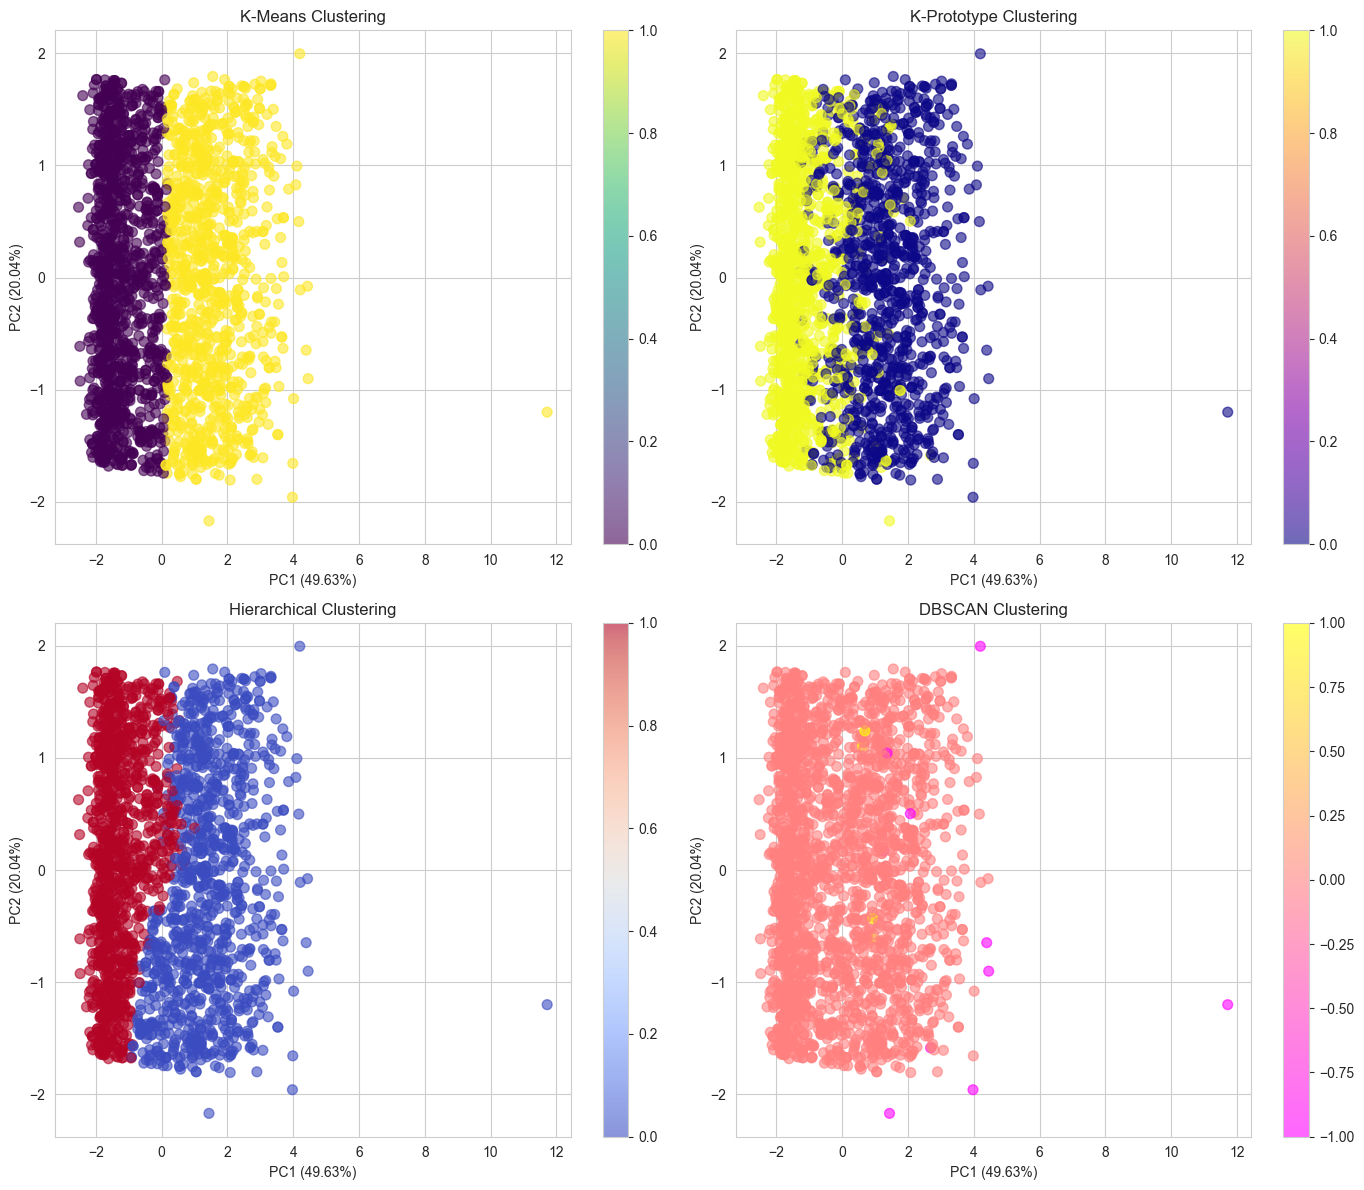

In [48]:
# Visualizar clustering resultados
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# K-Means
scatter1 = axes[0, 0].scatter(df_pca[:, 0], df_pca[:, 1], c=df_cluster['KMeans_Label'], 
                              cmap='viridis', alpha=0.6, s=50)
axes[0, 0].set_title('K-Means Clustering')
axes[0, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
axes[0, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.colorbar(scatter1, ax=axes[0, 0])

# K-Prototype
scatter2 = axes[0, 1].scatter(df_pca[:, 0], df_pca[:, 1], c=df_cluster['KPrototype_Label'], 
                              cmap='plasma', alpha=0.6, s=50)
axes[0, 1].set_title('K-Prototype Clustering')
axes[0, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
axes[0, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.colorbar(scatter2, ax=axes[0, 1])

# Hierarchical
scatter3 = axes[1, 0].scatter(df_pca[:, 0], df_pca[:, 1], c=df_cluster['Hierarchical_Label'], 
                              cmap='coolwarm', alpha=0.6, s=50)
axes[1, 0].set_title('Hierarchical Clustering')
axes[1, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
axes[1, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.colorbar(scatter3, ax=axes[1, 0])

# DBSCAN
scatter4 = axes[1, 1].scatter(df_pca[:, 0], df_pca[:, 1], c=df_cluster['DBSCAN_Label'], 
                              cmap='spring', alpha=0.6, s=50)
axes[1, 1].set_title('DBSCAN Clustering')
axes[1, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
axes[1, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.colorbar(scatter4, ax=axes[1, 1])

plt.tight_layout()
plt.show()

## 11. ANÁLISIS E INTERPRETACIÓN DE CLUSTERS (K-MEANS)

In [13]:
# Agregar etiquetas de cluster al dataframe original
df_original_with_clusters = df.copy()
df_original_with_clusters['Cluster'] = df_cluster['KMeans_Label']

# Analizar características por cluster
cluster_analysis = df_original_with_clusters.groupby('Cluster')[numeric_features].mean()

print("\n=== ANÁLISIS DE CLUSTERS (K-MEANS) ===")
print("\nPromedios por Cluster (Variables Numéricas):")
print(cluster_analysis.round(2))


=== ANÁLISIS DE CLUSTERS (K-MEANS) ===

Promedios por Cluster (Variables Numéricas):
           Income  Recency  MntWines  MntMeatProducts  NumWebPurchases
Cluster                                                               
0        37119.91    48.77     68.62            34.46             2.53
1        70980.71    49.53    596.79           331.83             6.02


In [14]:
# Análisis de variables categóricas por cluster
print("\nDistribución de Education por Cluster:")
edu_by_cluster = pd.crosstab(df_original_with_clusters['Cluster'], 
                             df_original_with_clusters['Education'], 
                             normalize='index')
print((edu_by_cluster * 100).round(2))

print("\nDistribución de Marital_Status por Cluster:")
marital_by_cluster = pd.crosstab(df_original_with_clusters['Cluster'], 
                                 df_original_with_clusters['Marital_Status'], 
                                 normalize='index')
print((marital_by_cluster * 100).round(2))


Distribución de Education por Cluster:
Education  2n Cycle  Basic  Graduation  Master    PhD
Cluster                                              
0             10.31   4.27       49.76   16.51  19.16
1              7.52   0.10       51.00   16.53  24.85

Distribución de Marital_Status por Cluster:
Marital_Status  Absurd  Alone  Divorced  Married  Single  Together  Widow  \
Cluster                                                                     
0                  0.0   0.16      9.98    38.65   22.71     25.93   2.58   
1                  0.2   0.10     10.82    38.48   19.84     25.85   4.51   

Marital_Status  YOLO  
Cluster               
0                0.0  
1                0.2  


## 12. VISUALIZACIÓN DE PERFILES DE CLUSTER

In [51]:
# Normalizar datos del análisis para visualización (radar chart)
from sklearn.preprocessing import MinMaxScaler

scaler_viz = MinMaxScaler()
cluster_analysis_scaled = pd.DataFrame(
    scaler_viz.fit_transform(cluster_analysis),
    columns=cluster_analysis.columns,
    index=cluster_analysis.index
)

print("Análisis de Clusters (Escalado 0-1 para visualización):")
print(cluster_analysis_scaled.round(2))

Análisis de Clusters (Escalado 0-1 para visualización):
         Income  Recency  MntWines  MntMeatProducts  NumWebPurchases
Cluster                                                             
0           0.0      0.0       0.0              0.0              0.0
1           1.0      1.0       1.0              1.0              1.0


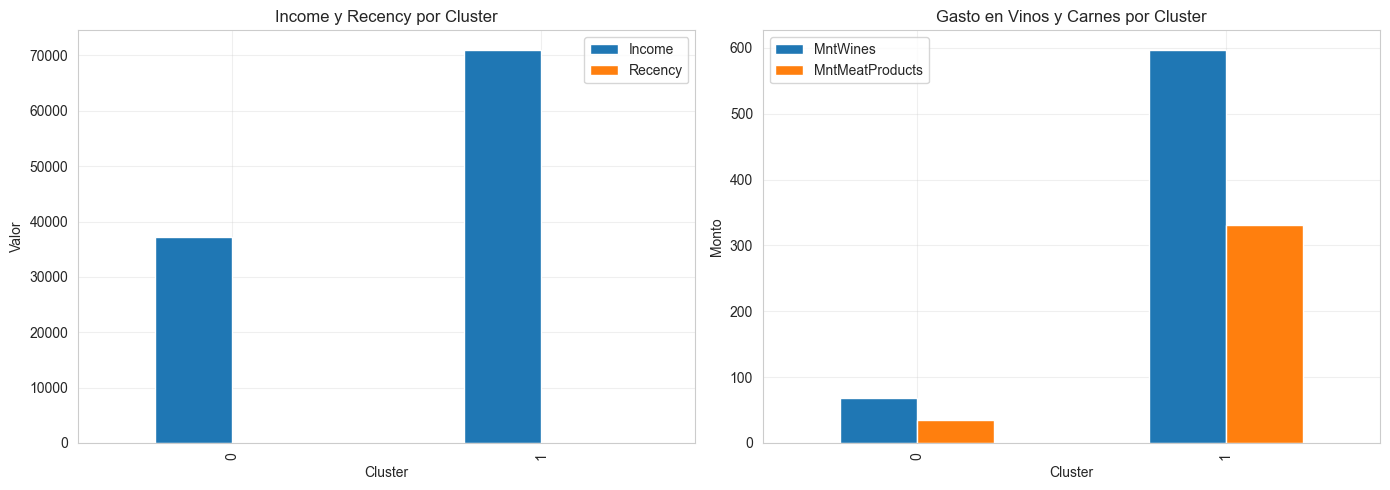

In [52]:
# Gráfico de barras comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Income vs Recency
cluster_analysis[['Income', 'Recency']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Income y Recency por Cluster')
axes[0].set_ylabel('Valor')
axes[0].set_xlabel('Cluster')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gasto en Vinos y Carnes
cluster_analysis[['MntWines', 'MntMeatProducts']].plot(kind='bar', ax=axes[1])
axes[1].set_title('Gasto en Vinos y Carnes por Cluster')
axes[1].set_ylabel('Monto')
axes[1].set_xlabel('Cluster')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 13. CONCLUSIONES Y INTERPRETACIÓN

In [54]:
print("\n" + "="*60)
print("RESUMEN DEL ANÁLISIS DE CLUSTERING")
print("="*60)

print(f"\n📊 Datos: {df.shape[0]} observaciones, {len(numeric_features)} variables numéricas, {len(categorical_features)} categóricas")
print(f"\n🎯 Modelo Seleccionado: K-Means con k={optimal_k} clusters")
print(f"   - Silhouette Score: {silhouette_kmeans:.4f}")
print(f"   - Davies-Bouldin Index: {davies_bouldin_kmeans:.4f}")
print(f"   - Calinski-Harabasz Index: {calinski_kmeans:.4f}")

print(f"\n💡 Interpretación de Clusters:")
for cluster_id in range(optimal_k):
    cluster_size = (df_cluster['KMeans_Label'] == cluster_id).sum()
    pct = (cluster_size / len(df_cluster)) * 100
    print(f"\n   Cluster {cluster_id}: {cluster_size} observaciones ({pct:.1f}%)")
    
    # Características principales
    for col in numeric_features:
        avg_val = cluster_analysis.loc[cluster_id, col]
        overall_avg = df_original_with_clusters[col].mean()
        diff_pct = ((avg_val - overall_avg) / overall_avg) * 100
        symbol = "↑" if diff_pct > 0 else "↓"
        print(f"      {col}: {avg_val:.0f} {symbol} ({diff_pct:+.1f}%)")

print(f"\n\n🔍 Métodos Alternativos Evaluados:")
print(f"   - K-Prototype: Maneja variables mixtas directamente")
print(f"   - Hierarchical Clustering: Proporciona dendrograma para exploración")
print(f"   - DBSCAN: Identifica outliers automáticamente")

print(f"\n✅ Recomendación: K-Means es eficiente y proporciona clusters interpretables para segmentación.")
print("="*60)


RESUMEN DEL ANÁLISIS DE CLUSTERING

📊 Datos: 2240 observaciones, 5 variables numéricas, 2 categóricas

🎯 Modelo Seleccionado: K-Means con k=2 clusters
   - Silhouette Score: 0.3686
   - Davies-Bouldin Index: 1.1548
   - Calinski-Harabasz Index: 1339.0493

💡 Interpretación de Clusters:

   Cluster 0: 1242 observaciones (55.4%)
      Income: 37120 ↓ (-29.0%)
      Recency: 49 ↓ (-0.7%)
      MntWines: 69 ↓ (-77.4%)
      MntMeatProducts: 34 ↓ (-79.4%)
      NumWebPurchases: 3 ↓ (-38.1%)

   Cluster 1: 998 observaciones (44.6%)
      Income: 70981 ↑ (+35.9%)
      Recency: 50 ↑ (+0.9%)
      MntWines: 597 ↑ (+96.4%)
      MntMeatProducts: 332 ↑ (+98.8%)
      NumWebPurchases: 6 ↑ (+47.4%)


🔍 Métodos Alternativos Evaluados:
   - K-Prototype: Maneja variables mixtas directamente
   - Hierarchical Clustering: Proporciona dendrograma para exploración
   - DBSCAN: Identifica outliers automáticamente

✅ Recomendación: K-Means es eficiente y proporciona clusters interpretables para segmentació

In [17]:
df_original_with_clusters.head(2)   

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Cluster
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,0,3,11,1,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,0,3,11,0,0


In [18]:
df_agg = df_original_with_clusters.groupby(['Cluster']).agg(nro_clientes=('Cluster', 'count'),
                                 nro_cli_target=('Response', 'sum'))
# efectividad esperadada por cluster
df_agg['efectividad_esperada'] = df_agg['nro_cli_target'] / df_agg['nro_clientes']
df_agg

,nro_clientes,nro_cli_target,efectividad_esperada
Cluster,,,
0,1242,119,0.095813
1,998,215,0.215431


In [20]:
pd.set_option('display.max_columns', None)

In [21]:
df_original_with_clusters.groupby(['Cluster']).describe()

ID                                                           \
          count         mean          std  min      25%     50%      75%   
Cluster                                                                    
0        1242.0  5586.709340  3263.052605  9.0  2750.50  5511.5  8371.25   
1         998.0  5598.942886  3227.769453  0.0  2887.25  5391.0  8543.00   

                 Year_Birth                                                  \
             max      count         mean        std     min     25%     50%   
Cluster                                                                       
0        11191.0     1242.0  1970.413849  11.545003  1893.0  1962.0  1972.0   
1        11181.0      998.0  1966.804609  12.222564  1899.0  1957.0  1967.0   

                         Income                                                \
            75%     max   count          mean           std     min       25%   
Cluster                                                                         
0        1978.0  1996.0  1226.0  37119.909462  13314.426890  1730.0  27428.25   
1        1976.0  1995.0   990.0  70980.707071  23762.869037  2447.0  61847.25   

                                     Kidhome                                \
             50%       75%       max   count      mean       std  min  25%   
Cluster                                                                      
0        36958.0  46138.50   79941.0  1242.0  0.701288  0.525098  0.0  0.0   
1        70103.5  78769.25  666666.0   998.0  0.124248  0.350659  0.0  0.0   

                       Teenhome                                               \
         50%  75%  max    count      mean       std  min  25%  50%  75%  max   
Cluster                                                                        
0        1.0  1.0  2.0   1242.0  0.511272  0.535856  0.0  0.0  0.0  1.0  2.0   
1        0.0  0.0  2.0    998.0  0.500000  0.555360  0.0  0.0  0.0  1.0  2.0   

        Recency                                                    MntWines  \
          count       mean        std  min   25%   50%   75%   max    count   
Cluster                                                                       
0        1242.0  48.771337  29.020305  0.0  24.0  49.0  75.0  99.0   1242.0   
1         998.0  49.530060  28.899310  0.0  25.0  51.0  73.0  99.0    998.0   

                                                                    MntFruits  \
               mean         std  min     25%    50%     75%     max     count   
Cluster                                                                         
0         68.617552   83.925024  0.0   10.00   29.0   99.75   459.0    1242.0   
1        596.786573  301.396801  1.0  374.25  539.0  789.00  1493.0     998.0   

                                                             MntMeatProducts  \
              mean        std  min   25%   50%    75%    max           count   
Cluster                                                                        
0         8.134461  16.039600  0.0   1.0   3.0   8.00  172.0          1242.0   
1        48.911824  48.056994  0.0  12.0  32.0  73.75  199.0           998.0   

                                                                    \
               mean         std  min    25%    50%     75%     max   
Cluster                                                              
0         34.463768   40.583445  0.0    9.0   18.0   46.00   270.0   
1        331.827655  251.568289  1.0  134.0  259.5  460.75  1725.0   

        MntFishProducts                                                       \
                  count       mean        std  min   25%   50%    75%    max   
Cluster                                                                        
0                1242.0  11.843800  22.605714  0.0   2.0   4.0   12.0  227.0   
1                 998.0  69.485972  64.975432  0.0  16.0  50.0  104.0  259.0   

        MntSweetProducts                                                       \
  